Running simulation for mu = 0.2...
Running simulation for mu = 1.0...
Running simulation for mu = 1.5...


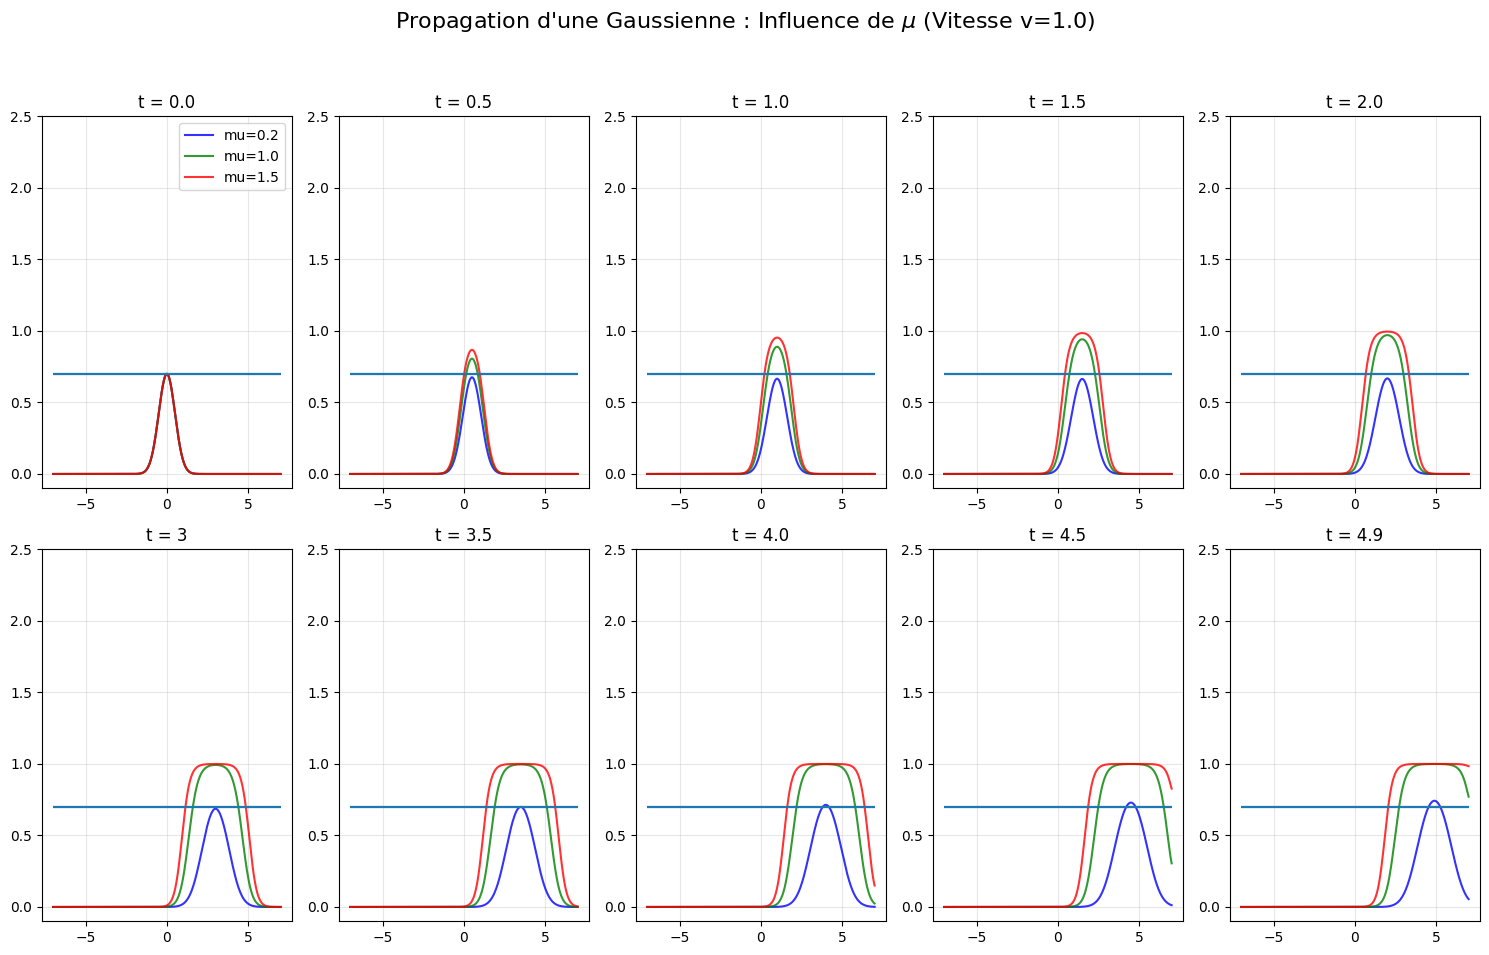

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from src.physics.solver import crank_nicolson_adr
from config import Config

def simulate_mu_variants():
    # 1. Configuration des paramètres communs
    x_min, x_max = Config.x_min, Config.x_max
    Nx = 400            # Résolution spatiale fine
    T_max = 5.0
    dt_sim = 0.001       # Pas de temps interne du solveur
    Nt = int(T_max / dt_sim)
    
    # Temps pour les snapshots (10 instants)
    t_snapshots = [0., 0.5, 1., 1.5, 2., 3, 3.5, 4., 4.5, 4.9]
    indices_t = [int(t / dt_sim) for t in t_snapshots]
    
    # Paramètres de la Gaussienne (Type 3)
    p_base = {
        'v': 1.0, 'D': 0.05, 'A': 0.7, 
        'x0': 0.0, 'sigma': 0.5, 'k': 1.0
    }
    
    mu_values = [0.2, 1.0, 1.5]
    colors = ['blue', 'green', 'red']
    
    plt.figure(figsize=(15, 10))
    
    # 2. Boucle sur les valeurs de Mu
    for mu, color in zip(mu_values, colors):
        print(f"Running simulation for mu = {mu}...")
        
        # Définition de l'IC (Gaussienne centrée en x0)
        x_eval = np.linspace(x_min, x_max, Nx)
        u0 = p_base['A'] * np.exp(-(x_eval - p_base['x0'])**2 / (2 * p_base['sigma']**2))
        
        # Appel du solveur
        # Note: On utilise 'neumann_zero' pour laisser la physique évoluer librement
        x, U, t = crank_nicolson_adr(
            v=p_base['v'], D=p_base['D'], mu=mu,
            xL=x_min, xR=x_max, Nx=Nx,
            Tmax=T_max, Nt=Nt, bc_kind="neumann_zero",
            x0=x_eval, u0=u0
        )
        
        # 3. Plot des snapshots
        for i, idx in enumerate(indices_t):
            label = f"mu={mu}" if i == 0 else ""
            plt.subplot(2, 5, i+1)
            plt.plot(x, U[idx, :], color=color, label=label, alpha=0.8)
            plt.title(f"t = {t_snapshots[i]}")
            plt.hlines(y=0.7,xmin = x_min, xmax = x_max)
            plt.ylim(-0.1, 2.5) # On laisse de la place pour la croissance (mu > 0)
            plt.grid(True, alpha=0.3)
            if i == 0: plt.legend()

    plt.suptitle(f"Propagation d'une Gaussienne : Influence de $\mu$ (Vitesse v=1.0)", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

if __name__ == "__main__":
    simulate_mu_variants()

In [2]:


# --- CELLULE 2 : FONCTION DE TEST ---
def run_smoke_test_notebook():
    print("🚀 DÉMARRAGE DU SMOKE TEST (Notebook Mode)...")

    # 1. OVERRIDE CONFIG (Version très légère pour le test)
    print("   🔧 Modification Config pour test rapide...")
    Config.n_warmup = 10           
    Config.n_iters_per_step = 20   
    Config.T_max = 0.2             
    Config.n_sample = 50           
    Config.batch_size = 16         
    Config.max_retry = 1
    # On sauvegarde dans un dossier spécifique
    Config.save_dir = "./test_results_notebook" 
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    if torch.backends.mps.is_available(): device = torch.device("mps")
    print(f"   📱 Device : {device}")

    # 2. INIT
    print("   🏗️ Initialisation modèle...")
    model = PI_DeepONet_ADR().to(device)

    # 3. TRAIN
    print("   🏋️ Entraînement rapide...")
    try:
        model = train_smart_time_marching(
            model, 
            bounds=Config.ranges, 
            n_warmup=Config.n_warmup, 
            n_iters_per_step=Config.n_iters_per_step
        )
    except Exception as e:
        print(f"❌ Erreur Training: {e}")
        return model # On retourne quand même pour inspecter

    # 4. PLOTS (Affichage direct)
    print("\n   🎨 Génération des plots...")
    os.makedirs(Config.save_dir, exist_ok=True)
    
    # On change le backend matplotlib temporairement pour afficher inline
    import matplotlib
    matplotlib.use('module://matplotlib_inline.backend_inline')
    
    try:
        # Snapshots
        compare_model_vs_cn_snapshots(model, save_dir=Config.save_dir)
        plt.show() # Force l'affichage
        print("   ✅ Snapshots générés.")
    except Exception as e: print(f"   ❌ Erreur Snapshots: {e}")

    try:
        # Heatmaps
        plot_error_heatmaps(model, Config.x_min, Config.x_max, Config.T_max, save_dir=Config.save_dir)
        plt.show()
        print("   ✅ Heatmaps générées.")
    except Exception as e: print(f"   ❌ Erreur Heatmaps: {e}")

    return model

# --- CELLULE 3 : LANCEMENT ---
model_trained = run_smoke_test_notebook()

🚀 DÉMARRAGE DU SMOKE TEST (Notebook Mode)...
   🔧 Modification Config pour test rapide...
   📱 Device : mps
   🏗️ Initialisation modèle...
   🏋️ Entraînement rapide...
⚡ DÉMARRAGE TRAINING (Config Driven)
   -> Warmup (t=0): 10 iters
   -> Time Step: 0.1, Max T: 0.2
   -> Batch Size: 16

🧊 PHASE 0 : Fixation Condition Initiale (t=0)...


Warmup IC: 100%|████████████████████████████████████████████████████████████████████████| 10/10 [00:00<00:00, 18.70it/s]


   ✅ Warmup terminé.

⏳ --- PALIER TEMPOREL : [0, 0.1] ---


   ⚠️ Retry 1/1 (LR=5.0e-04, Err: 100.68%)...
   ❌ PALIER NON VALIDÉ (Err: 100.45%). Expansion forcée.

⏳ --- PALIER TEMPOREL : [0, 0.2] ---


   ⚠️ Retry 1/1 (LR=5.0e-04, Err: 99.79%)...
   ❌ PALIER NON VALIDÉ (Err: 105.79%). Expansion forcée.

🎉 Entraînement terminé.
Launching the statistical audit on 200 cases


100%|█████████████████████████████████████████████████████████████████████████████████| 200/200 [00:07<00:00, 28.29it/s]


Audit saved : ./test_results_notebook/global_audit_results.csv
Mean error L2: 107.74%

   🎨 Génération des plots...
✅ Figure sauvegardée : ./test_results_notebook/comparison_snapshots.png
   ✅ Snapshots générés.
✅ Heatmaps sauvegardées : ./test_results_notebook/error_heatmaps.png
   ✅ Heatmaps générées.


In [3]:
%%writefile launch.slurm
#!/bin/bash
#SBATCH --job-name=DeepONet_ADR     # Nom du job
#SBATCH --output=slurm/log/%x_%j.out
#SBATCH --error=slurm/log/%x_%j.err
#SBATCH -A fdb@v100                 # <--- TON COMPTE PROJET ICI
#SBATCH --constraint=v100-32g
#SBATCH --nodes=1
#SBATCH --ntasks=1
#SBATCH --gres=gpu:1
#SBATCH --cpus-per-task=10
#SBATCH --hint=nomultithread
#SBATCH --time=20:00:00
#SBATCH --qos=qos_gpu-t3

# Nettoyage
module purge
module load pytorch-gpu/py3/2.1.1

# Création du dossier de logs (au cas où)
mkdir -p slurm/log

echo "🚀 Job lancé sur $SLURMD_NODENAME"
nvidia-smi

# Lancement de ton script d'entraînement
srun python train.py

Writing launch.slurm


In [4]:
!sbatch launch.slurm

zsh:1: command not found: sbatch
